# Análise Exploratória Inicial

### Visão Geral e Cardinalidade

Esta etapa permite uma visão exaustiva da distribuição dos dados. A análise de todas as entidades é essencial para identificar quais clientes ou servidores possuem amostras insuficientes para a aplicação de algoritmos de CPD, permitindo uma filtragem fundamentada antes da modelagem.

Total de medições: 351978
Total de clientes distintos: 17
Total de servidores distintos: 11
Total de pares cliente-servidor distintos: 179


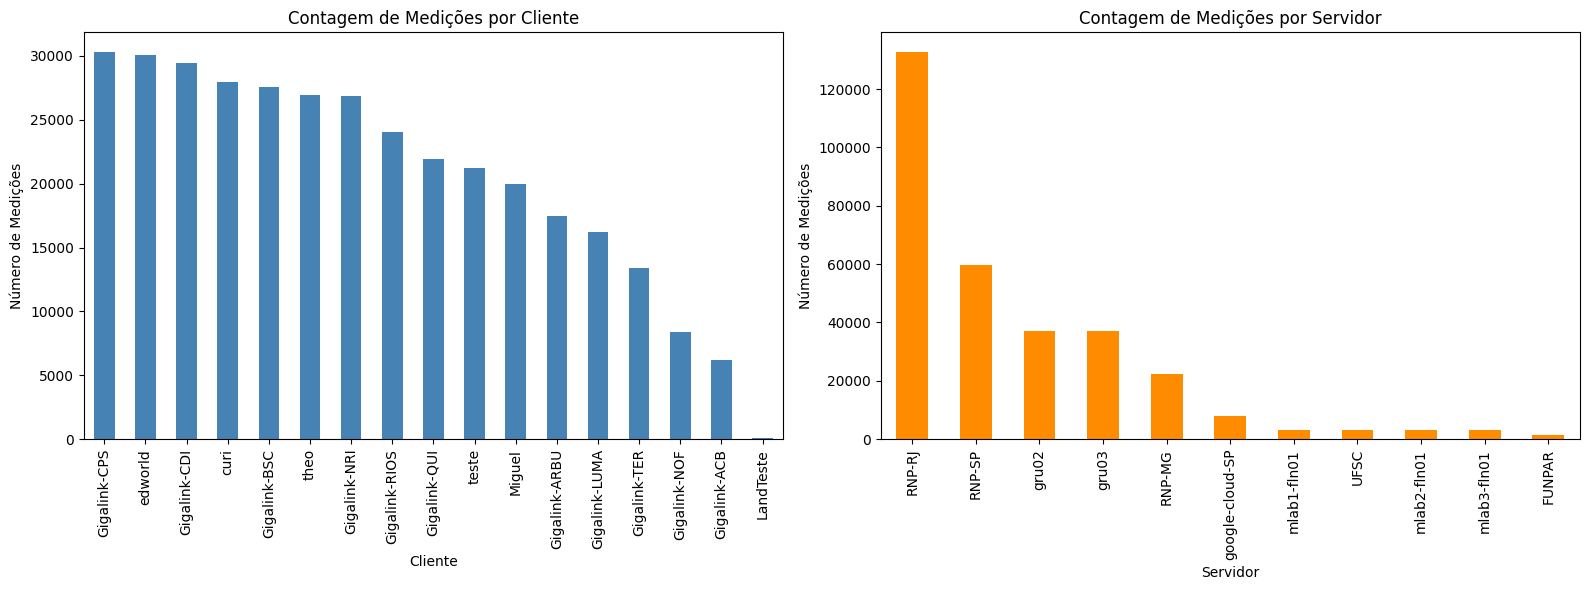

In [198]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Carregamento do dataset
file = 'NOV_ABR_transformed.csv'
# file = 'NOV_ABR_clean.csv'
file_path = os.path.join("NDT dataset", file)
df = pd.read_csv(file_path)
clean = True

# Conversão de timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Criar coluna de par cliente-servidor
df['client_server_pair'] = df['client_name'] + " -> " + df['server_name']

# Contagens Gerais
total_medicoes = len(df)
num_clientes = df['client_name'].nunique()
num_servidores = df['server_name'].nunique()
num_pares = df['client_server_pair'].nunique()

print(f"Total de medições: {total_medicoes}")
print(f"Total de clientes distintos: {num_clientes}")
print(f"Total de servidores distintos: {num_servidores}")
print(f"Total de pares cliente-servidor distintos: {num_pares}")

# Distribuição por Cliente e Servidor
medicoes_por_cliente = df['client_name'].value_counts()
medicoes_por_servidor = df['server_name'].value_counts()

# Plotagem em Gráficos de Barras
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Clientes
medicoes_por_cliente.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Contagem de Medições por Cliente')
axes[0].set_ylabel('Número de Medições')
axes[0].set_xlabel('Cliente')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico de Servidores
medicoes_por_servidor.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Contagem de Medições por Servidor')
axes[1].set_ylabel('Número de Medições')
axes[1].set_xlabel('Servidor')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [199]:
if clean:
    # Remover os x clientes menos comuns
    clientes_para_remover = medicoes_por_cliente.nsmallest(3).index
    df = df[~df['client_name'].isin(clientes_para_remover)]
    # Manter apenas os x servidores mais comuns
    top_servidores = df['server_name'].value_counts().nlargest(5).index
    df = df[df['server_name'].isin(top_servidores)]

### Verificação de Valores Nulos e Negativos

Esta etapa visa identificar a presença de dados faltantes (nulos) e valores numéricos inconsistentes, como registros negativos em métricas de rede que devem ser estritamente positivas (throughput, latência e taxa de perda). A detecção prévia destas anomalias é indispensável para garantir a integridade da série temporal e evitar distorções matemáticas durante a aplicação do algoritmo de *Changepoint Detection*.


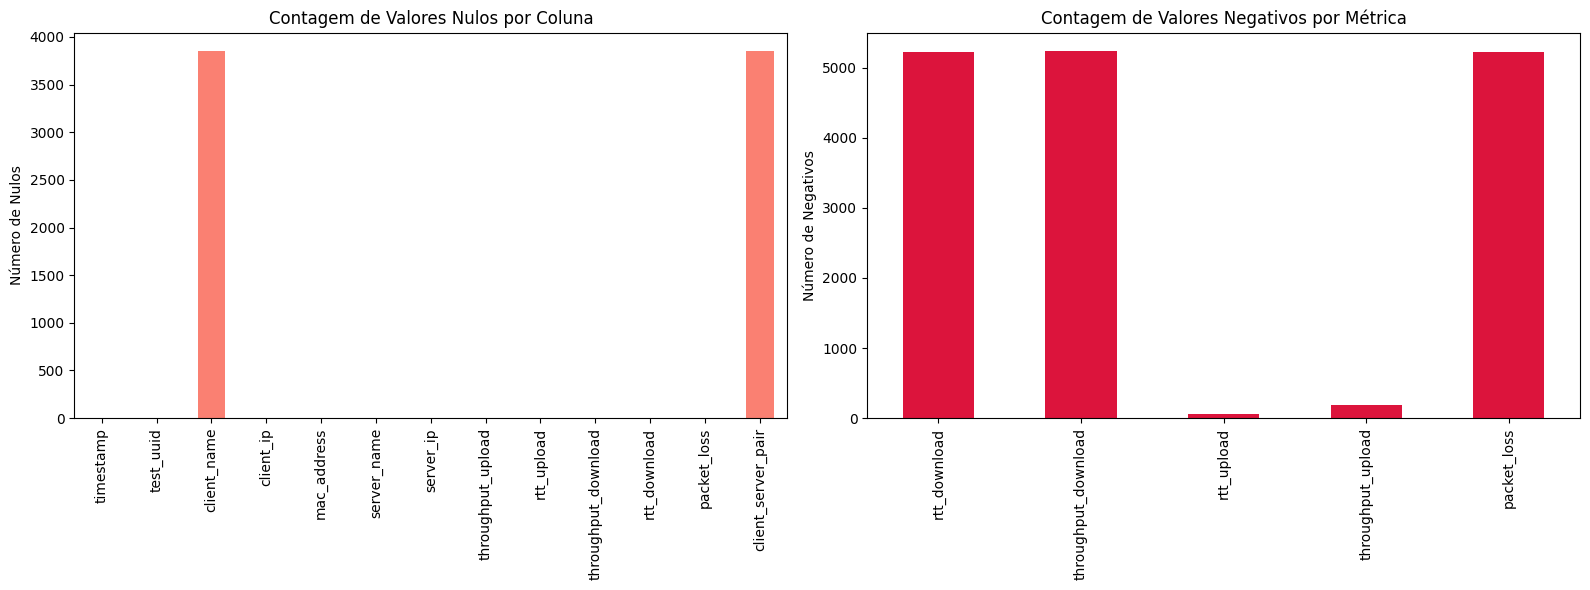

In [200]:
import matplotlib.pyplot as plt
import pandas as pd

nulos = df.isnull().sum()

metricas = [
    'rtt_download', 'throughput_download', 
    'rtt_upload', 'throughput_upload', 'packet_loss'
]
negativos = {col: (df[col] < 0).sum() for col in metricas if col in df.columns}
negativos_series = pd.Series(negativos)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

nulos.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Contagem de Valores Nulos por Coluna')
axes[0].set_ylabel('Número de Nulos')
axes[0].tick_params(axis='x', rotation=90)

negativos_series.plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Contagem de Valores Negativos por Métrica')
axes[1].set_ylabel('Número de Negativos')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [201]:
if clean:
    # remover os valores nulos
    df = df.dropna()
    # remover os valores negativos
    for col in metricas:
        if col in df.columns:
            df = df[df[col] >= 0]


### Verificação de Pares Cliente-Servidor

Esta etapa quantifica as combinações únicas de clientes e servidores presentes no dataset. O objetivo é identificar o número total de fluxos de comunicação distintos antes de prosseguir com a análise de distribuição temporal e avaliação de constância para cada par.

Total de pares cliente-servidor distintos: 70


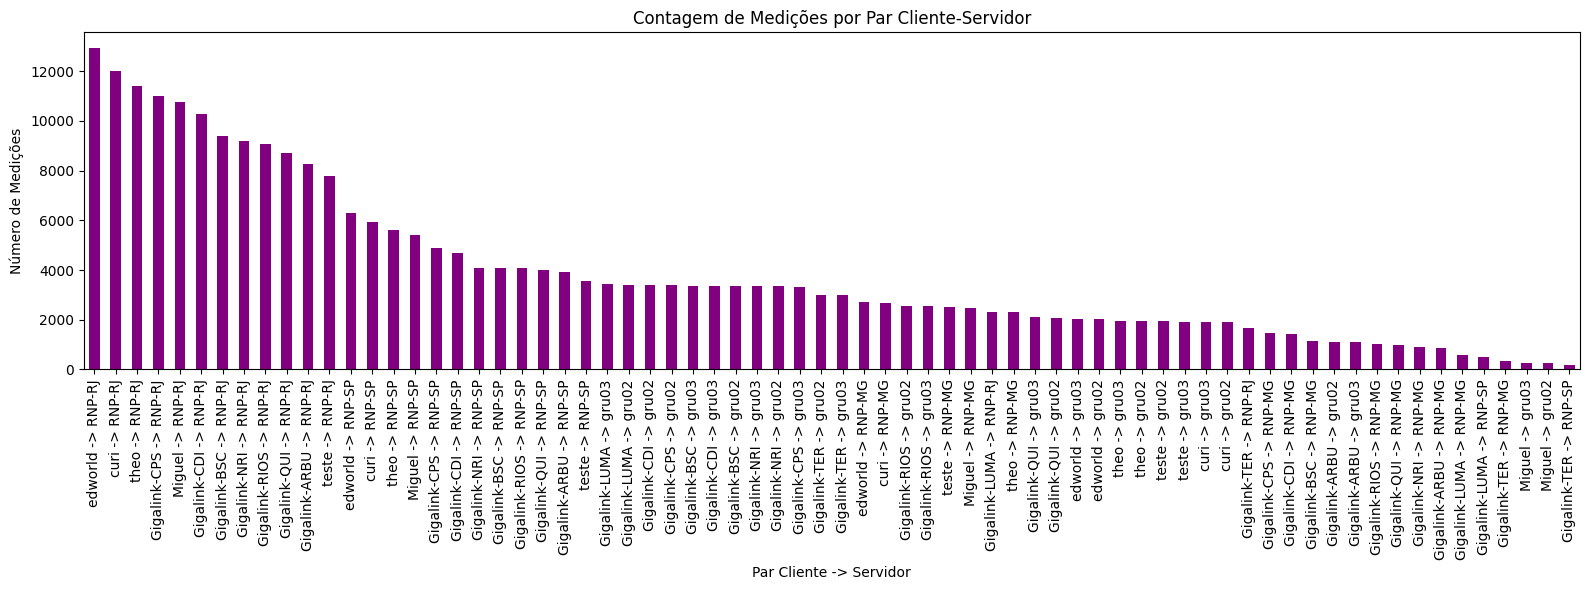

In [202]:
num_pares = df['client_server_pair'].nunique()
print(f"Total de pares cliente-servidor distintos: {num_pares}")

medicoes_por_par = df['client_server_pair'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
medicoes_por_par.plot(kind='bar', color='purple')
plt.title('Contagem de Medições por Par Cliente-Servidor')
plt.xlabel('Par Cliente -> Servidor')
plt.ylabel('Número de Medições')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [203]:
if clean:
    # remover os pares com menos de x000 medições
    df = df[df['client_server_pair'].isin(medicoes_por_par[medicoes_por_par >= 3000].index)]

### Verificação de Timestamps Duplicados

Em análises de séries temporais e, especialmente, na aplicação de algoritmos de *Changepoint Detection* (CPD), a unicidade do índice de tempo para cada fluxo é um pré-requisito matemático rigoroso. A presença de *timestamps* duplicados para um mesmo par Cliente-Servidor indica que múltiplas medições foram registradas no exato mesmo instante, o que pode causar falhas em janelas móveis (*rolling windows*), cálculos de variância e quebrar a execução de rotinas de exportação ou modelagem. Esta etapa quantifica essas ocorrências.

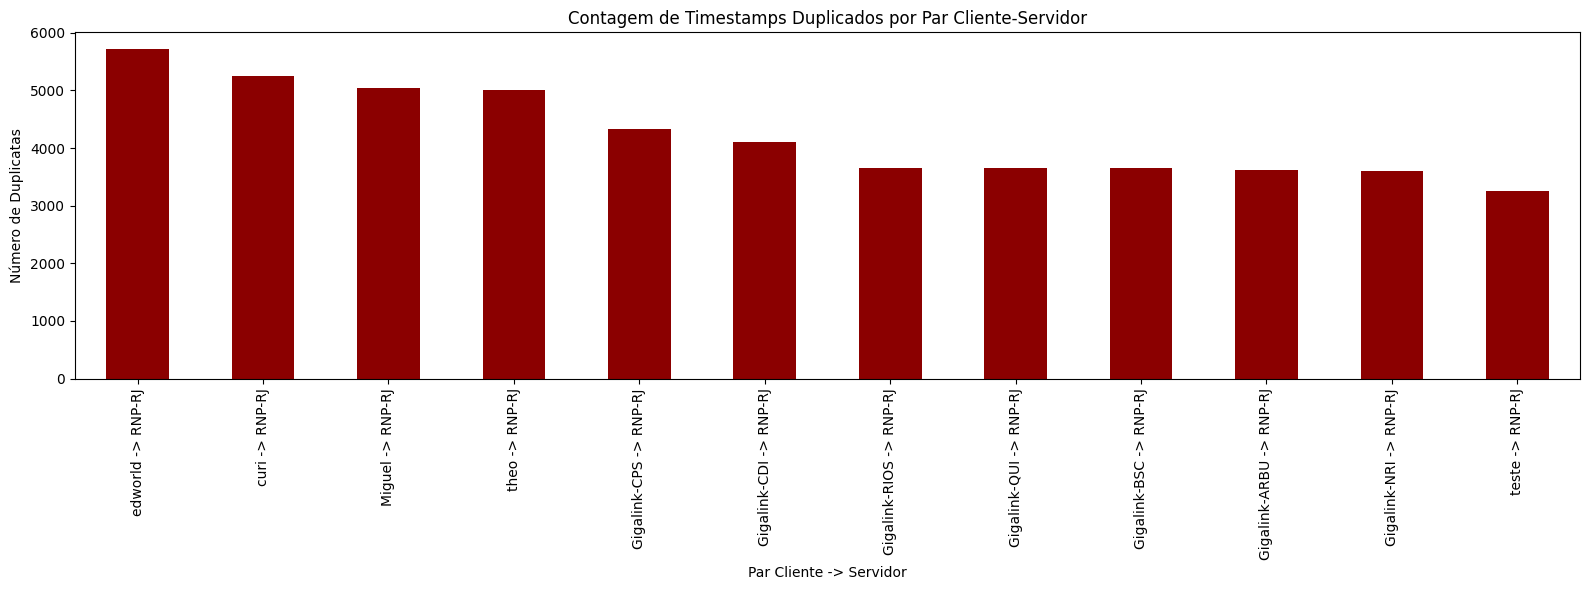

Total de pares afetados: 12
Total absoluto de registros duplicados a serem tratados: 50864


In [204]:
import pandas as pd
import matplotlib.pyplot as plt

if 'client_server_pair' not in df.columns:
    df['client_server_pair'] = df['client_name'] + " -> " + df['server_name']

duplicatas = df.duplicated(subset=['client_server_pair', 'timestamp'])
pares_com_duplicatas = duplicatas.groupby(df['client_server_pair']).sum()
pares_com_duplicatas = pares_com_duplicatas[pares_com_duplicatas > 0].sort_values(ascending=False)

if pares_com_duplicatas.empty:
    print("Nenhum par Cliente-Servidor possui timestamps duplicados. Os dados estão consistentes.")
else:
    plt.figure(figsize=(16, 6))
    pares_com_duplicatas.plot(kind='bar', color='darkred')
    plt.title('Contagem de Timestamps Duplicados por Par Cliente-Servidor')
    plt.xlabel('Par Cliente -> Servidor')
    plt.ylabel('Número de Duplicatas')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
    print(f"Total de pares afetados: {len(pares_com_duplicatas)}")
    print(f"Total absoluto de registros duplicados a serem tratados: {int(pares_com_duplicatas.sum())}")

In [205]:
if clean:
    # remover os pares com timestamps duplicados
    df = df[~df['client_server_pair'].isin(pares_com_duplicatas.keys())]

### Verificação de Entidades Remanescentes

Após a análise de constância temporal e possíveis filtragens de pares com dados esparsos ou lacunas excessivas, esta etapa contabiliza a quantidade atualizada de clientes e servidores que restaram no *dataset*. Essa verificação confirma o escopo final dos dados que serão submetidos ao algoritmo de detecção de *changepoints*.

Total de medições: 93276
Total de clientes distintos: 14
Total de servidores distintos: 3
Total de pares cliente-servidor distintos: 23


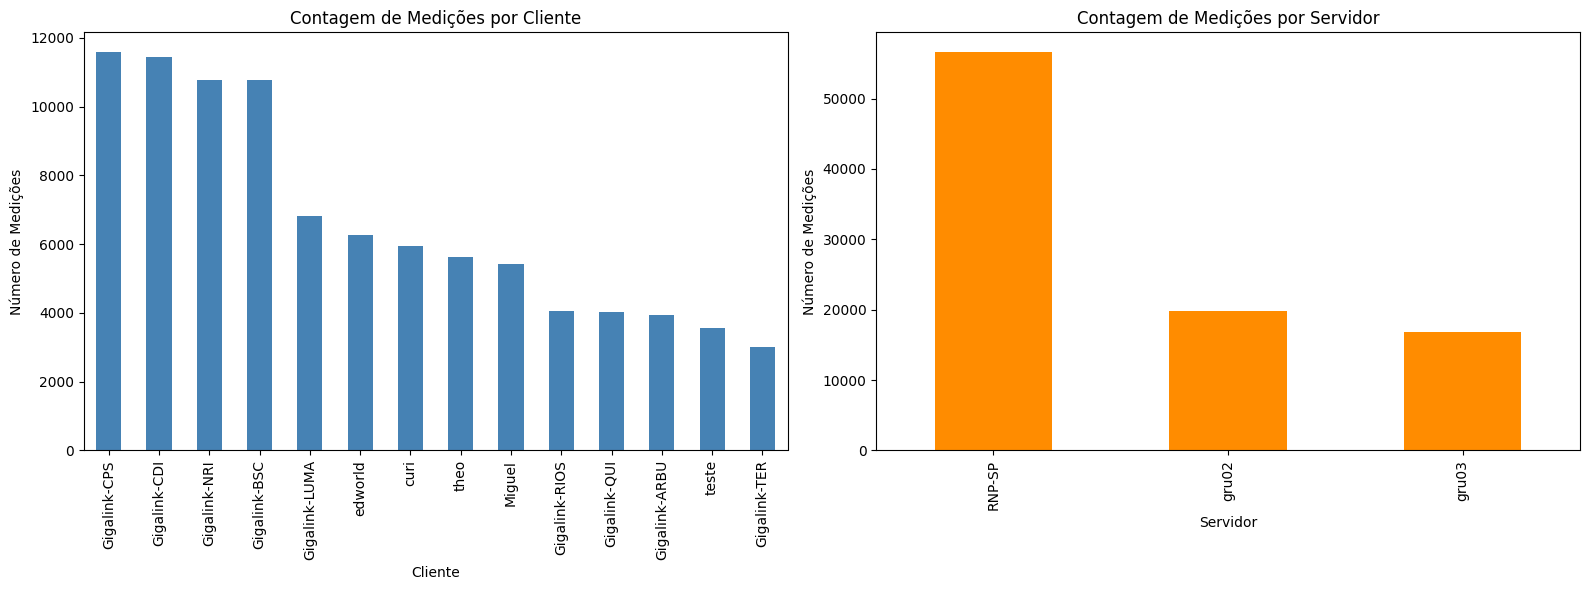

In [206]:
# Contagens Gerais
total_medicoes = len(df)
num_clientes = df['client_name'].nunique()
num_servidores = df['server_name'].nunique()
num_pares = df['client_server_pair'].nunique()

print(f"Total de medições: {total_medicoes}")
print(f"Total de clientes distintos: {num_clientes}")
print(f"Total de servidores distintos: {num_servidores}")
print(f"Total de pares cliente-servidor distintos: {num_pares}")

# Distribuição por Cliente e Servidor
medicoes_por_cliente = df['client_name'].value_counts()
medicoes_por_servidor = df['server_name'].value_counts()

# Plotagem em Gráficos de Barras
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Clientes
medicoes_por_cliente.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Contagem de Medições por Cliente')
axes[0].set_ylabel('Número de Medições')
axes[0].set_xlabel('Cliente')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico de Servidores
medicoes_por_servidor.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Contagem de Medições por Servidor')
axes[1].set_ylabel('Número de Medições')
axes[1].set_xlabel('Servidor')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Análise de Constância e Lacunas Temporais

Esta visualização utiliza um gráfico de dispersão (*scatter plot*) para avaliar a constância das medições ao longo do tempo. O eixo X representa a linha do tempo (do registro mais antigo ao mais recente) e o eixo Y lista cada par único de Cliente-Servidor. Cada ponto no gráfico corresponde a uma medição, permitindo a identificação visual de "buracos" — períodos prolongados sem coleta de dados para um determinado par —, o que é crucial para avaliar a continuidade da série temporal antes da aplicação de algoritmos de detecção de *changepoints*.

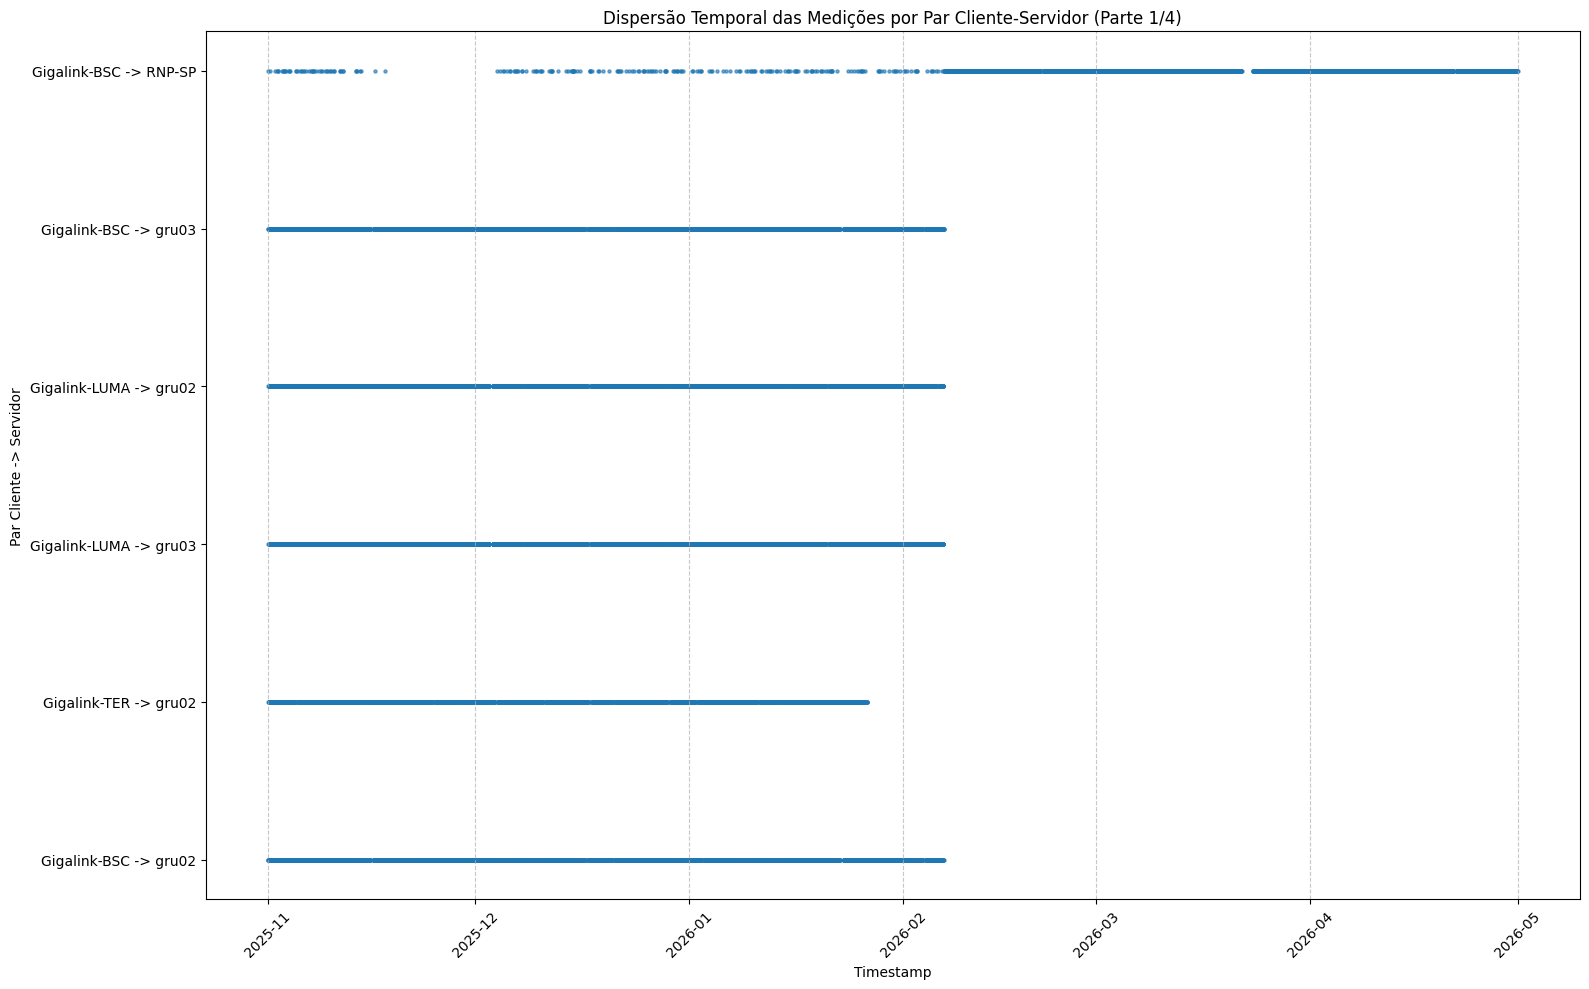

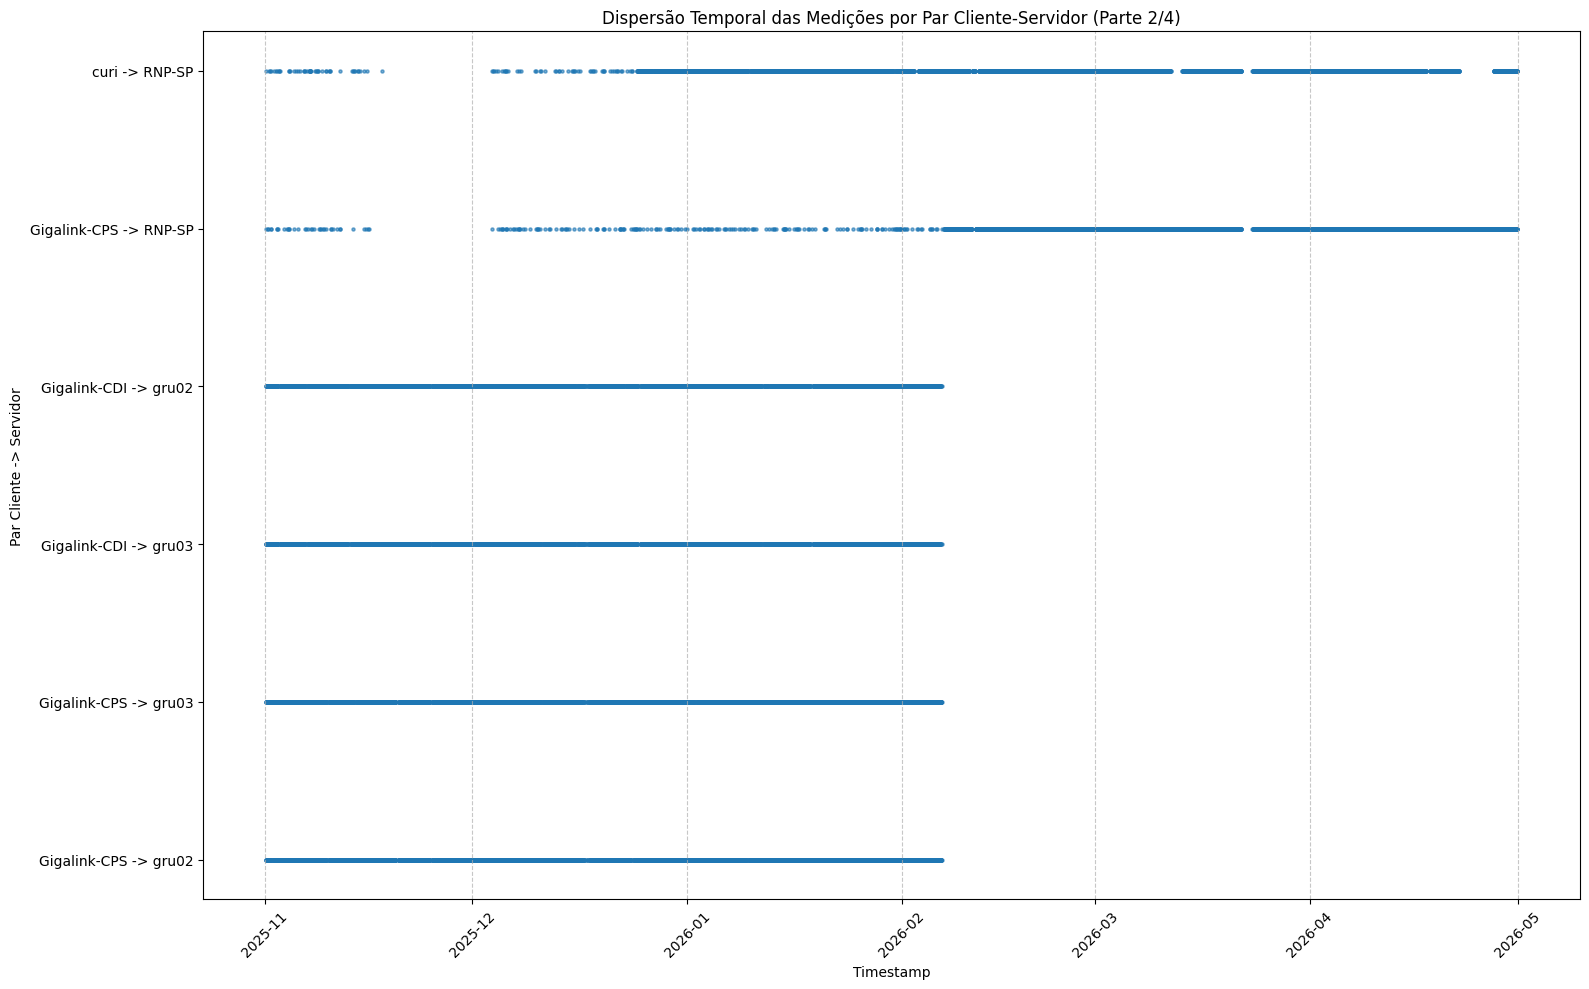

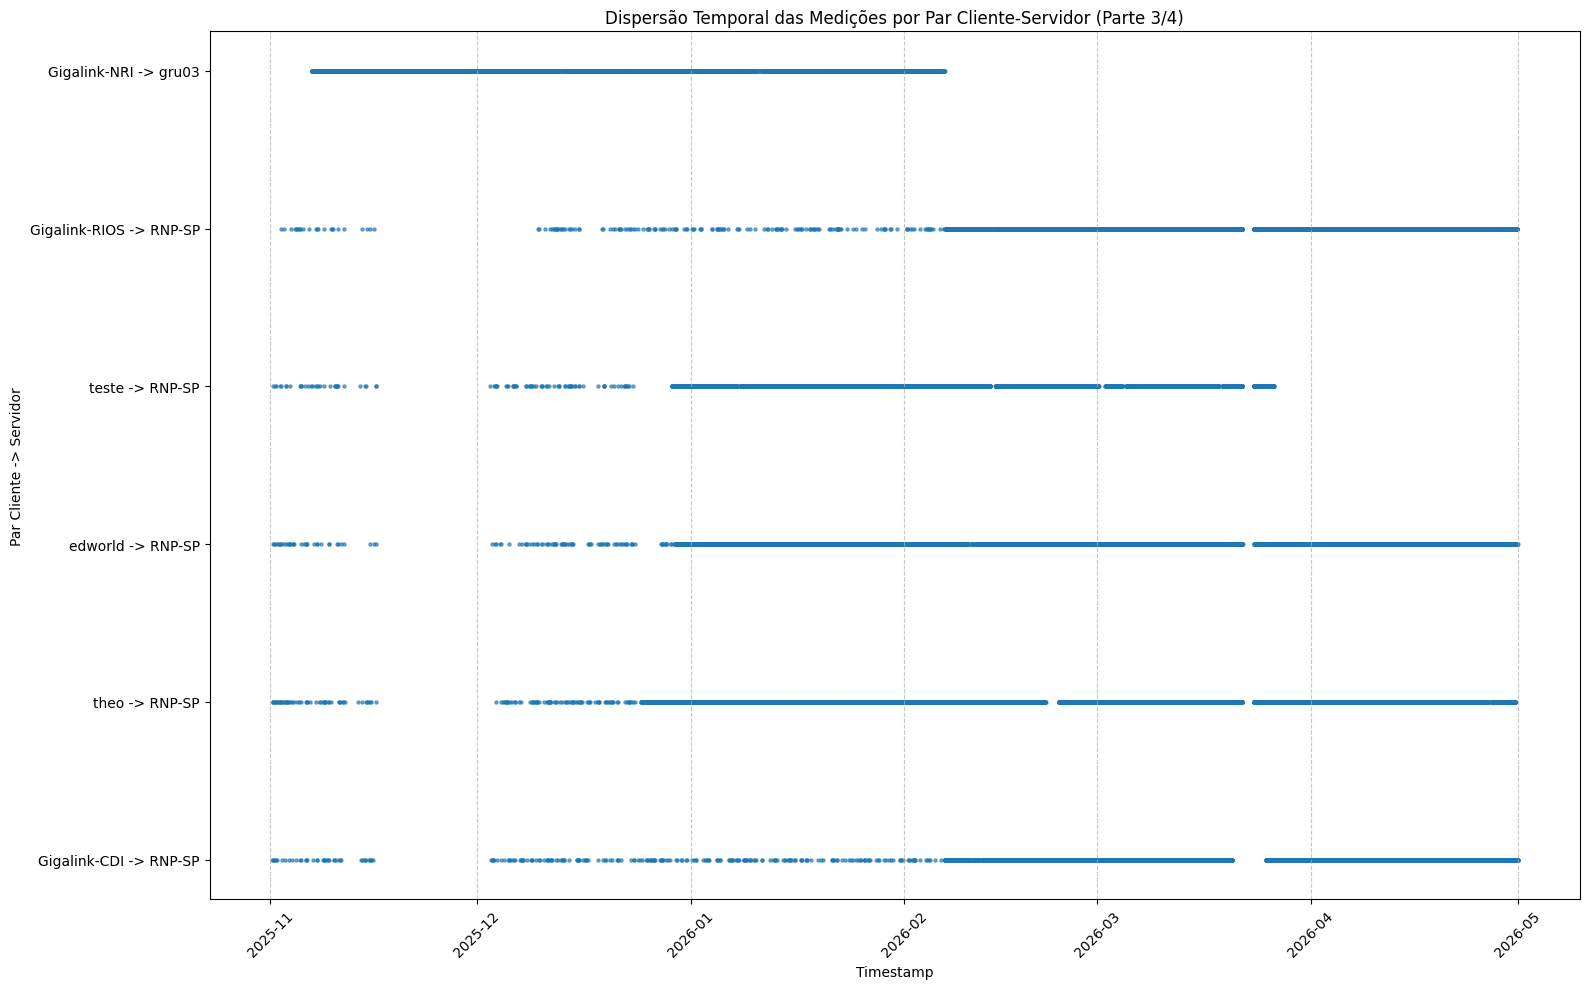

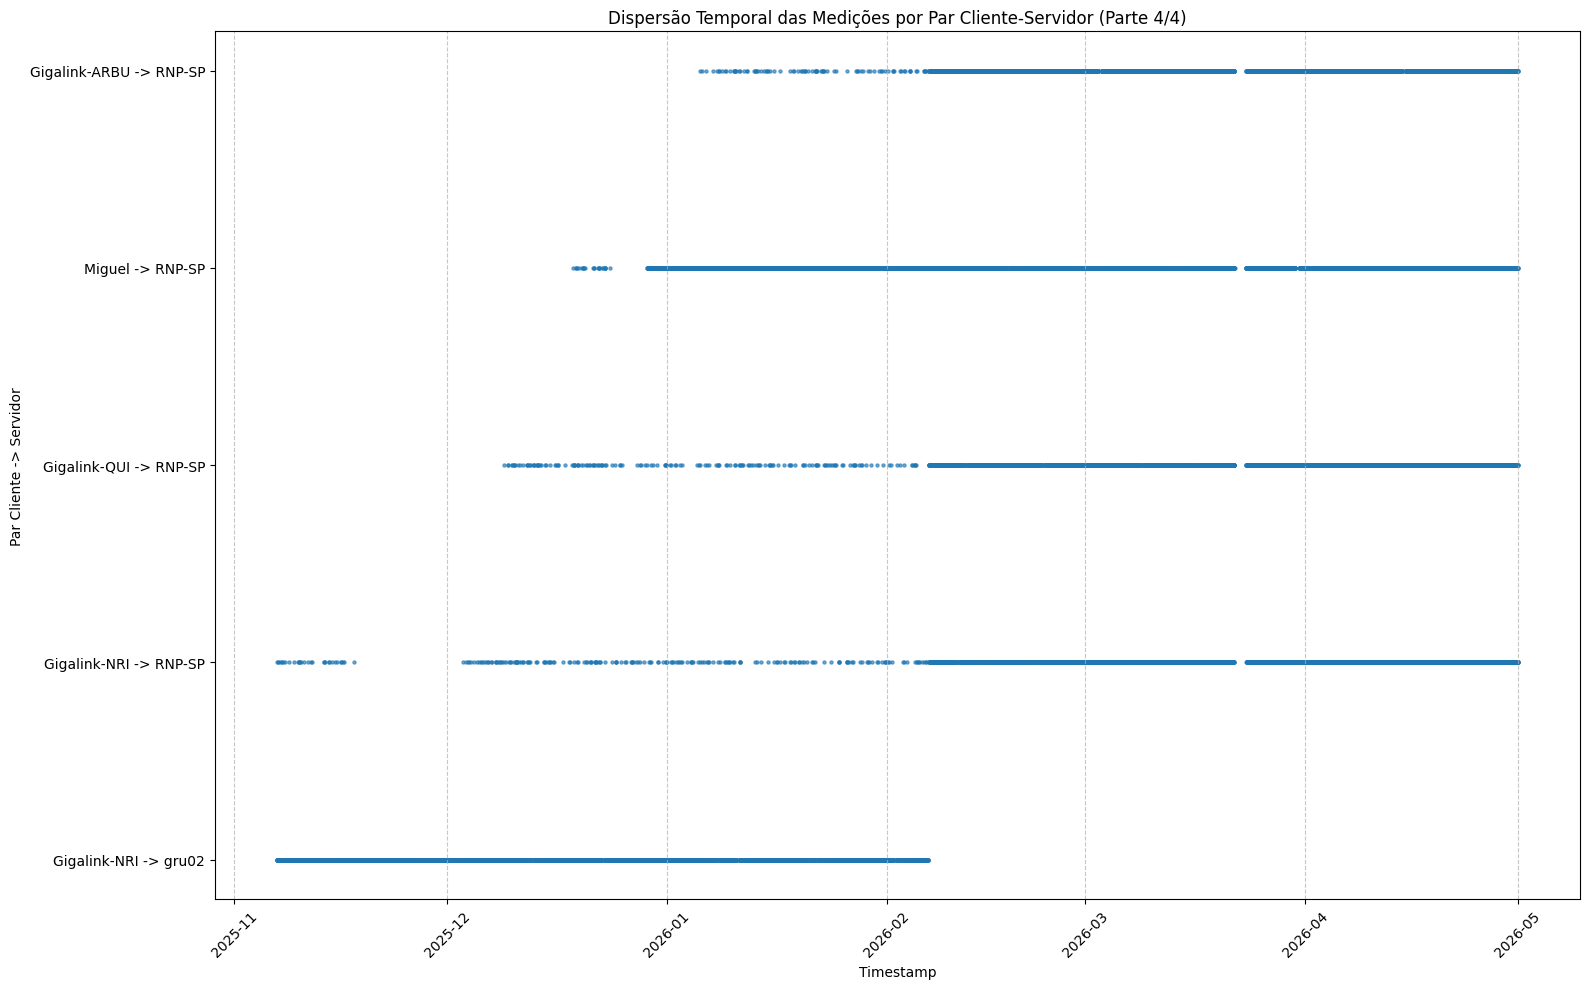

In [207]:
import matplotlib.pyplot as plt
import numpy as np

df = df.sort_values('timestamp')

pares_unicos = df['client_server_pair'].unique()
partes = np.array_split(pares_unicos, 4)

for i, parte in enumerate(partes, 1):
    df_parte = df[df['client_server_pair'].isin(parte)]
    
    plt.figure(figsize=(16, 10))
    plt.scatter(df_parte['timestamp'], df_parte['client_server_pair'], alpha=0.6, marker='.', s=20)
    plt.title(f'Dispersão Temporal das Medições por Par Cliente-Servidor (Parte {i}/{len(partes)})')
    plt.xlabel('Timestamp')
    plt.ylabel('Par Cliente -> Servidor')
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Distribuição de Dados e Detecção de Outliers

Esta etapa analisa o comportamento estatístico individual de cada métrica de rede. A utilização de **Histogramas** permite visualizar o formato da distribuição dos dados (identificando assimetrias, como a cauda longa comum em métricas de *throughput* e latência). Simultaneamente, os **Boxplots** fornecem um resumo visual da dispersão, destacando a mediana, os quartis e, crucialmente, os *outliers* (valores atípicos que podem representar anomalias reais da rede ou erros de medição a serem tratados antes da aplicação do modelo de *Changepoint Detection*).

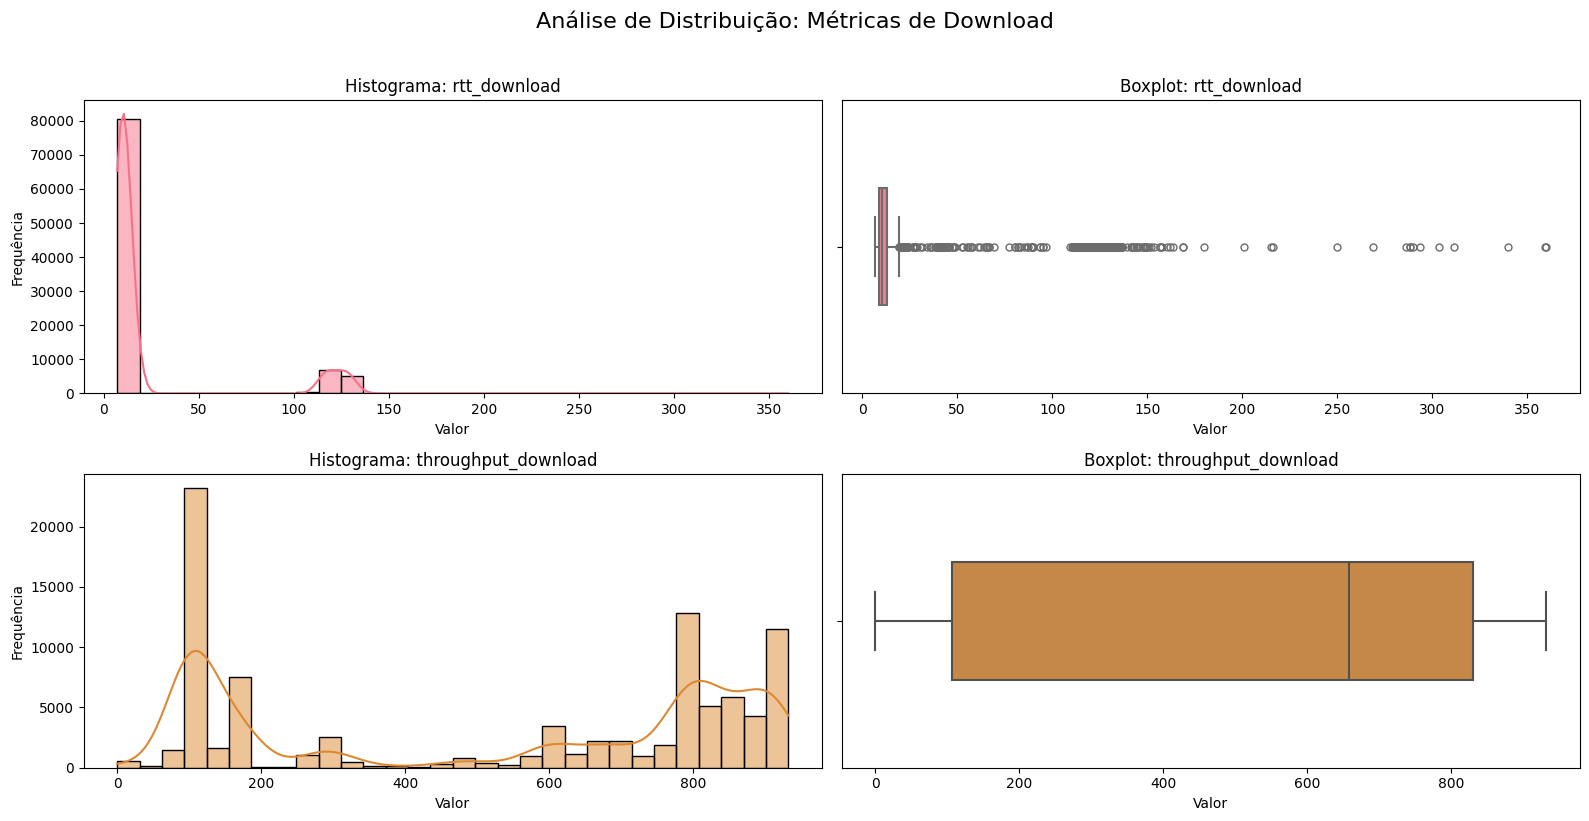

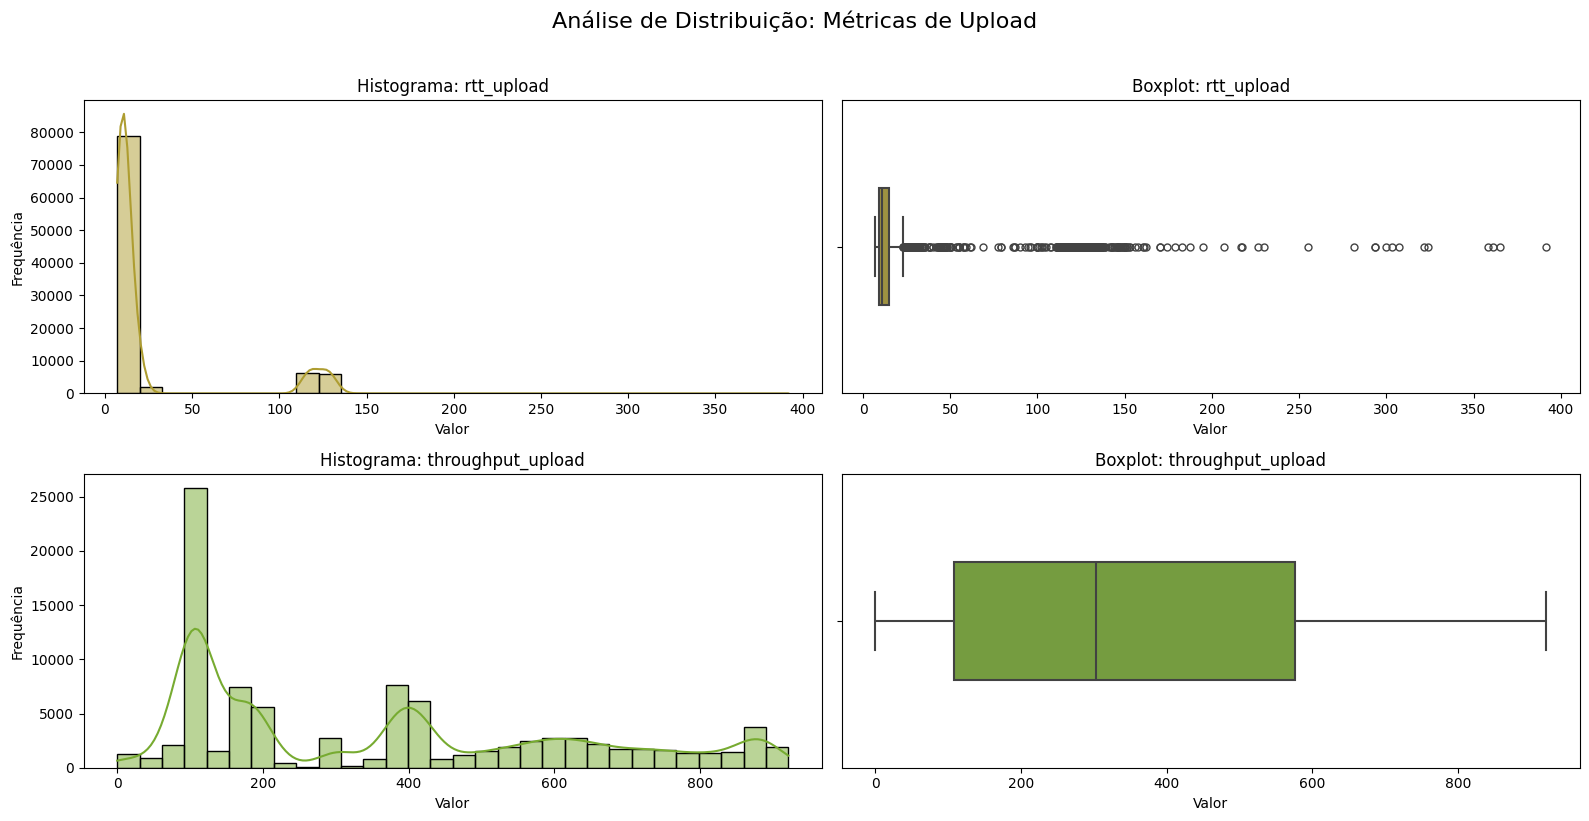

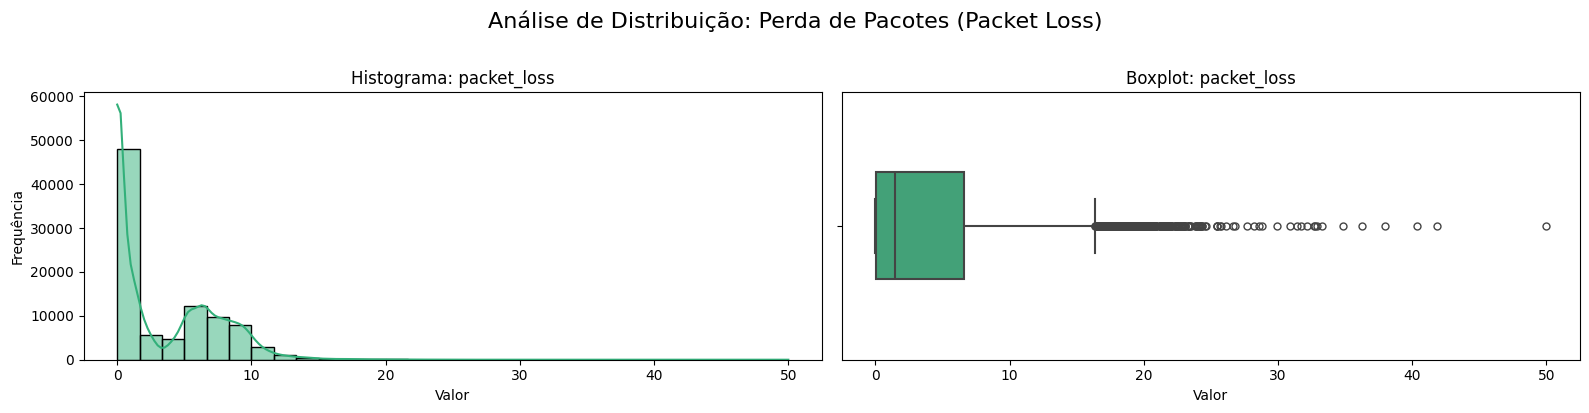

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

# Função auxiliar para gerar os gráficos padronizados por grupo sem tratamento interno
def plot_grupo_metricas(metrics, titulo, color_offset):
    metrics_exist = [m for m in metrics if m in df.columns]
    if not metrics_exist:
        return
        
    fig, axes = plt.subplots(nrows=len(metrics_exist), ncols=2, figsize=(16, 4 * len(metrics_exist)))
    palette = sns.color_palette("husl", 10)
    
    for i, col in enumerate(metrics_exist):
        # Tratar a indexação dos axes (se for só 1 linha, axes é 1D)
        if len(metrics_exist) == 1:
            ax_hist = axes[0]
            ax_box = axes[1]
        else:
            ax_hist = axes[i, 0]
            ax_box = axes[i, 1]
            
        color = palette[color_offset + i]
        
        # Histograma com KDE (direto da coluna, sem dropna)
        sns.histplot(df[col], kde=True, color=color, ax=ax_hist, bins=30)
        ax_hist.set_title(f'Histograma: {col}')
        ax_hist.set_xlabel('Valor')
        ax_hist.set_ylabel('Frequência')
        
        # Boxplot (direto da coluna, sem dropna)
        sns.boxplot(
            x=df[col], 
            color=color, 
            width=0.4, 
            fliersize=5, 
            linewidth=1.5,
            ax=ax_box
        )
        ax_box.set_title(f'Boxplot: {col}')
        ax_box.set_xlabel('Valor')

    plt.suptitle(titulo, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 1. Figura Exclusiva para Download
plot_grupo_metricas(
    ['rtt_download', 'throughput_download'], 
    'Análise de Distribuição: Métricas de Download', 
    color_offset=0
)

# 2. Figura Exclusiva para Upload
plot_grupo_metricas(
    ['rtt_upload', 'throughput_upload'], 
    'Análise de Distribuição: Métricas de Upload', 
    color_offset=2
)

# 3. Figura Exclusiva para Packet Loss
plot_grupo_metricas(
    ['packet_loss'], 
    'Análise de Distribuição: Perda de Pacotes (Packet Loss)', 
    color_offset=4
)